# GECS Industry & Sub-Industry Classification — Exploratory Data Analysis

**Project:** DePaul × Morningstar Capstone (Spring 2026)
**Author:** Meet Patel — Analytics & Modeling Lead
**Notebook:** `02_eda.ipynb`
**Last Updated:** April 2026

---

## Purpose

The cleaning notebook produced two parquet files. This notebook answers:

1. **What does our label space actually look like?** Class distributions at every level of the
   GECS hierarchy. Where is the long tail? Where is the imbalance?
2. **What does our text input look like?** Length distributions, missingness patterns, signal
   density per task.
3. **What modeling decisions does this lock in?** Stratification feasibility, baseline
   feature choices, success-criteria reachability per task.

## Output

Section C produces a **Modeling Readiness Table** that you can paste directly into the
project report. It is the headline deliverable of this notebook.

## Pipeline Position

```
01_cleaning.ipynb  →  cleaned parquet files
02_eda.ipynb       →  THIS NOTEBOOK
03_baseline.ipynb  →  TF-IDF + LogReg baseline (floor)
04_modeling.ipynb  →  Sentence-transformer / fine-tuned encoder
05_evaluation.ipynb →  Confusion analysis, hierarchical fallback eval
```

---
## 0. Imports & Environment Setup

In [1]:
# Standard library
import os
import re
import warnings
from pathlib import Path
from collections import Counter

# Numerical / data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

# Display
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns',  30)
pd.set_option('display.width',        200)

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.dpi']        = 100
plt.rcParams['savefig.dpi']       = 150
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top']   = False

# Sector palette — consistent across all charts
SECTOR_COLORS = {
    'Basic Materials':        '#8b5a3c',
    'Communication Services': '#9b59b6',
    'Consumer Cyclical':      '#e67e22',
    'Consumer Defensive':     '#27ae60',
    'Energy':                 '#c0392b',
    'Financial Services':     '#2980b9',
    'Healthcare':             '#16a085',
    'Industrials':            '#7f8c8d',
    'Real Estate':            '#d4ac0d',
    'Technology':             '#34495e',
    'Utilities':              '#5dade2',
}

print(f'pandas      : {pd.__version__}')
print(f'numpy       : {np.__version__}')

pandas      : 3.0.2
numpy       : 2.4.4


---
## 1. Configuration & Data Loading

Load both cleaned datasets. Task 2 needs hierarchy decomposition added here since the cleaning
notebook only does this for Task 1.

In [2]:
DATA_DIR = Path('../data/cleaned')
OUT_DIR  = Path('../reports')
OUT_DIR.mkdir(parents=True, exist_ok=True)

T1_PATH = DATA_DIR / 'task1_gecs_classification_final_cleaned.csv'
T2_PATH = DATA_DIR / 'task2_subindustry_classification_final_cleaned.csv'

# Reference maps (mirrors cleaning notebook)
SECTOR_MAP = {
    '101': 'Basic Materials',     '102': 'Consumer Cyclical',
    '103': 'Financial Services',  '104': 'Real Estate',
    '205': 'Consumer Defensive',  '206': 'Healthcare',
    '207': 'Utilities',           '308': 'Communication Services',
    '309': 'Energy',              '310': 'Industrials',
    '311': 'Technology',
}
SUPER_SECTOR_MAP = {'1': 'Cyclical', '2': 'Defensive', '3': 'Sensitive'}

# Load Task 1
df1 = pd.read_csv(T1_PATH, parse_dates=['AsOfDate'],
                  dtype={'MstarGlobal': str, 'CompanyId': str})
print(f'Task 1: {df1.shape}  ({df1.memory_usage(deep=True).sum()/1e6:.1f} MB)')

# Load Task 2 — decompose SubIndustry into hierarchy here
df2 = pd.read_csv(T2_PATH, parse_dates=['AsOfDate'],
                  dtype={'SubIndustry': str, 'CompanyId': str})
sub_str = df2['SubIndustry'].astype(str)
df2['super_sector_code']    = sub_str.str[0]
df2['sector_code']          = sub_str.str[:3]
df2['industry_group_code']  = sub_str.str[:5]
df2['parent_industry_code'] = sub_str.str[:8]   # ← this matches Task 1's MstarGlobal
df2['super_sector_name']    = df2['super_sector_code'].map(SUPER_SECTOR_MAP)
df2['sector_name']          = df2['sector_code'].map(SECTOR_MAP)
print(f'Task 2: {df2.shape}  ({df2.memory_usage(deep=True).sum()/1e6:.1f} MB)')

print(f'\nTask 2 hierarchy levels extracted:')
print(f'  Super sectors        : {df2["super_sector_code"].nunique()}')
print(f'  Sectors              : {df2["sector_code"].nunique()}')
print(f'  Industry groups      : {df2["industry_group_code"].nunique()}')
print(f'  Parent industries    : {df2["parent_industry_code"].nunique()}')
print(f'  SubIndustries (label): {df2["SubIndustry"].nunique()}')

Task 1: (53575, 25)  (100.6 MB)
Task 2: (27157, 21)  (18.7 MB)

Task 2 hierarchy levels extracted:
  Super sectors        : 3
  Sectors              : 11
  Industry groups      : 55
  Parent industries    : 145
  SubIndustries (label): 428


---
# Section A — Task 1: Industry Classification

**145 classes | 53,575 rows | text-rich (829 char median combined_text)**

The headline question for Task 1 is not class imbalance (manageable) — it's the **51% missing
SegmentDescription** that the cleaning notebook surfaced. Most of this section is geared toward
understanding how that missingness is distributed.

## A1. Dataset Overview

Records              : 53,575
Unique companies     : 23,207
Records per company  : avg 2.3, median 2, max 32
Date range           : 2003-12-31 → 2024-12-31
Unique AsOfDates     : 55

Industries observed  : 145 / 145
Sectors observed     : 11 / 11


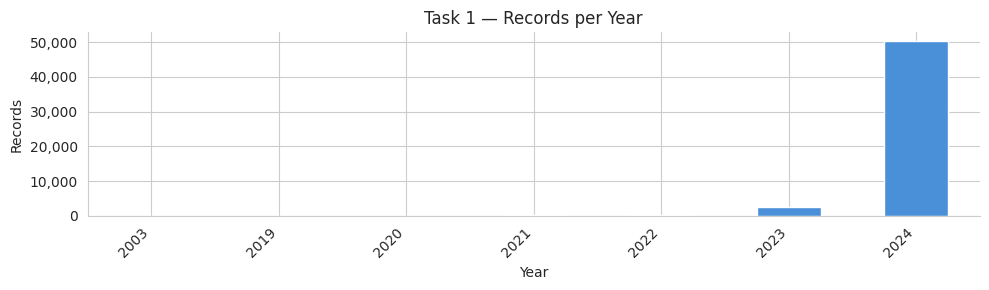

In [3]:
print(f'Records              : {len(df1):,}')
print(f'Unique companies     : {df1["CompanyId"].nunique():,}')
print(f'Records per company  : avg {len(df1)/df1["CompanyId"].nunique():.1f}, '
      f'median {df1.groupby("CompanyId").size().median():.0f}, '
      f'max {df1.groupby("CompanyId").size().max()}')
print(f'Date range           : {df1["AsOfDate"].min().date()} → {df1["AsOfDate"].max().date()}')
print(f'Unique AsOfDates     : {df1["AsOfDate"].nunique()}')
print()
print(f'Industries observed  : {df1["MstarGlobal"].nunique()} / 145')
print(f'Sectors observed     : {df1["sector_code"].nunique()} / 11')

# Companies per year — coverage check
year_counts = df1.groupby(df1['AsOfDate'].dt.year).size()
fig, ax = plt.subplots(figsize=(10, 3))
year_counts.plot(kind='bar', ax=ax, color='#4a90d9')
ax.set_title('Task 1 — Records per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Records')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## A2. GECS Hierarchy Distribution

Distribution at every level of the hierarchy. Each chart reveals a different aspect of imbalance.

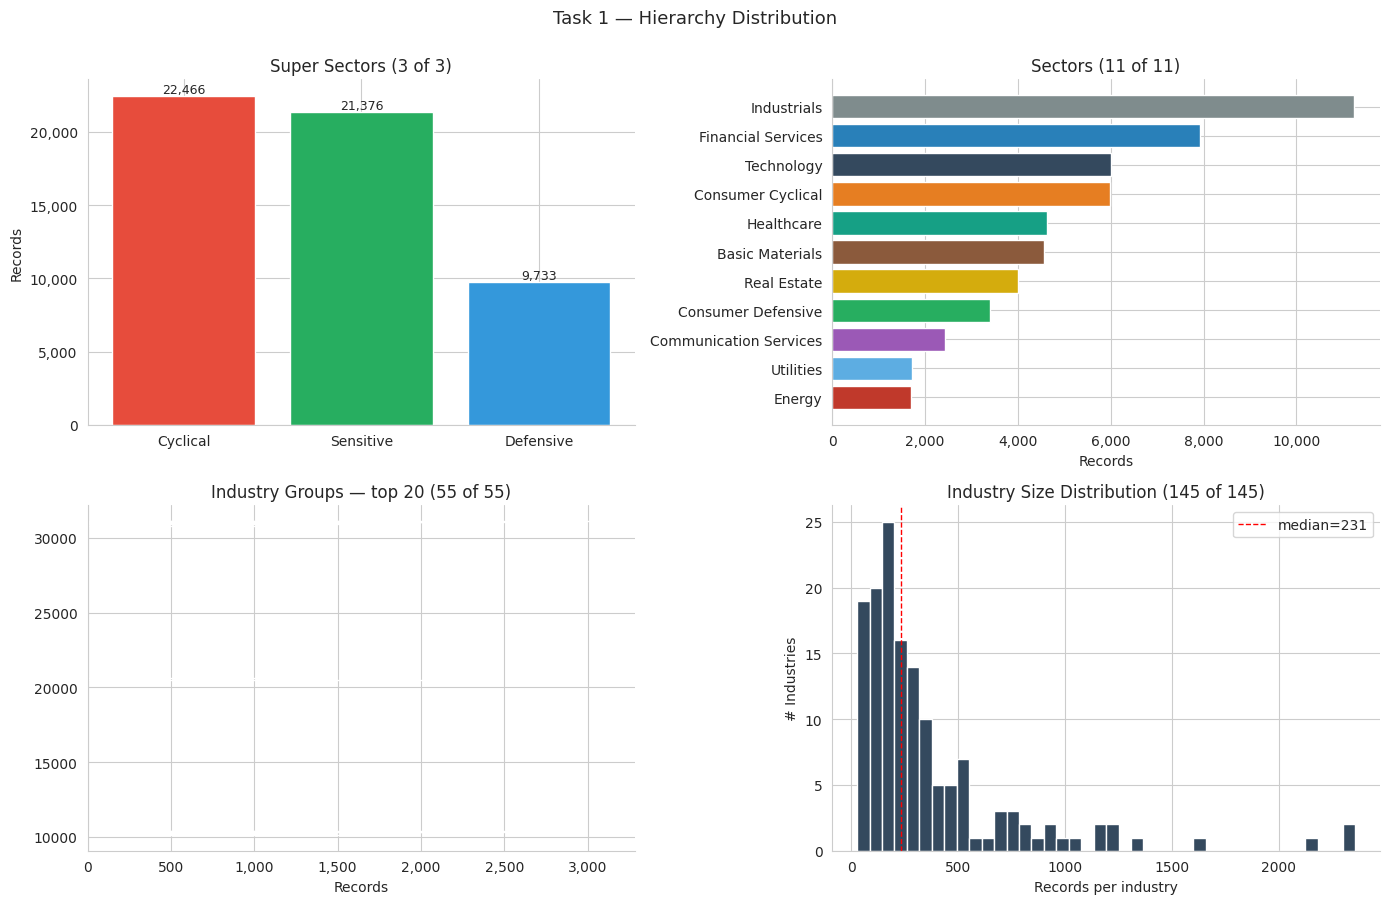

Industry size: min=28  median=231  max=2358  imbalance=84.2x


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Super Sector
ss = df1['super_sector_name'].value_counts()
axes[0,0].bar(ss.index, ss.values, color=['#e74c3c','#27ae60','#3498db'])
axes[0,0].set_title(f'Super Sectors ({df1["super_sector_name"].nunique()} of 3)')
axes[0,0].set_ylabel('Records')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, (k, v) in enumerate(ss.items()):
    axes[0,0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

# Sector
sec = df1['sector_name'].value_counts()
colors = [SECTOR_COLORS.get(s, '#888') for s in sec.index]
axes[0,1].barh(sec.index[::-1], sec.values[::-1], color=colors[::-1])
axes[0,1].set_title(f'Sectors ({df1["sector_name"].nunique()} of 11)')
axes[0,1].set_xlabel('Records')
axes[0,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Industry Group (top 20)
ig = df1['industry_group_code'].value_counts().head(20)
axes[1,0].barh(ig.index[::-1], ig.values[::-1], color='#7f8c8d')
axes[1,0].set_title(f'Industry Groups — top 20 ({df1["industry_group_code"].nunique()} of 55)')
axes[1,0].set_xlabel('Records')
axes[1,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Industry size distribution
ind_counts = df1['MstarGlobal'].value_counts()
axes[1,1].hist(ind_counts.values, bins=40, color='#34495e', edgecolor='white')
axes[1,1].set_title(f'Industry Size Distribution ({df1["MstarGlobal"].nunique()} of 145)')
axes[1,1].set_xlabel('Records per industry')
axes[1,1].set_ylabel('# Industries')
axes[1,1].axvline(ind_counts.median(), color='red', linestyle='--', lw=1, label=f'median={int(ind_counts.median())}')
axes[1,1].legend()

plt.suptitle('Task 1 — Hierarchy Distribution', fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

# Numbers
print(f'Industry size: min={ind_counts.min()}  median={int(ind_counts.median())}  '
      f'max={ind_counts.max()}  imbalance={ind_counts.max()/ind_counts.min():.1f}x')

## A3. Industry-Level Class Imbalance

For modeling we care less about absolute imbalance and more about whether **class weights** can
fix it (yes, ratio <100×) or if we need **rare-class handling** (no, ratio >1000×).

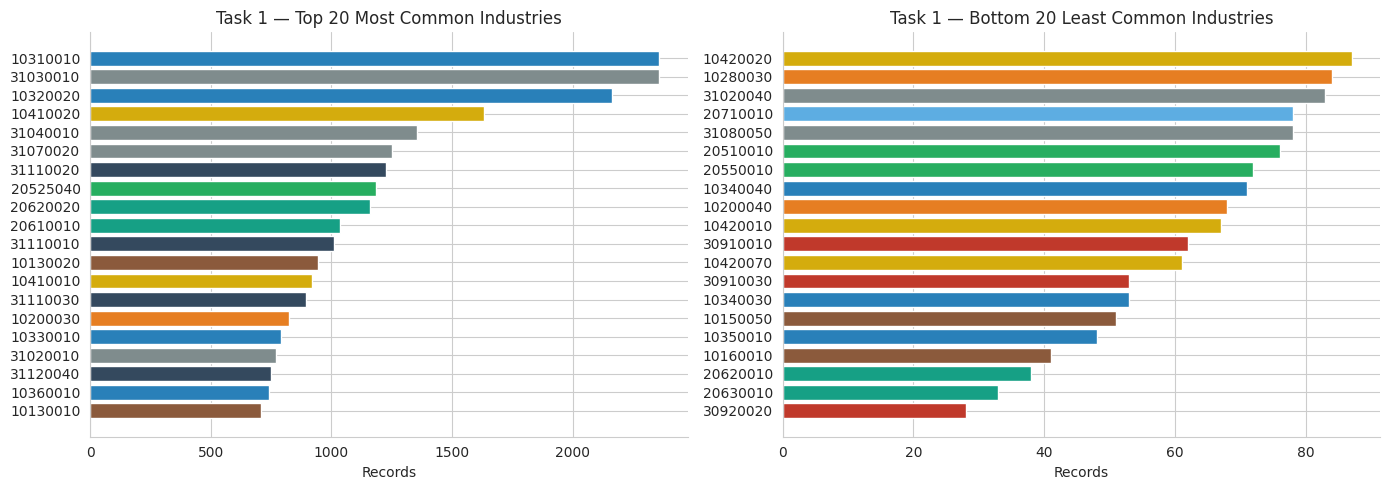

Industries with <30 samples :   1  (rare regime)
Industries with <50 samples :   5
Industries with <100 samples:  21

Min samples per industry: 28  → safe for stratified split ✓


In [5]:
ind_counts = df1['MstarGlobal'].value_counts()
class_sector = df1.groupby('MstarGlobal')['sector_name'].first()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 20 + sector coloring
top20 = ind_counts.head(20)
top20_colors = [SECTOR_COLORS.get(class_sector[c], '#888') for c in top20.index]
axes[0].barh(top20.index.astype(str)[::-1], top20.values[::-1], color=top20_colors[::-1])
axes[0].set_title('Task 1 — Top 20 Most Common Industries')
axes[0].set_xlabel('Records')

# Bottom 20
bot20 = ind_counts.tail(20)
bot20_colors = [SECTOR_COLORS.get(class_sector[c], '#888') for c in bot20.index]
axes[1].barh(bot20.index.astype(str)[::-1], bot20.values[::-1], color=bot20_colors[::-1])
axes[1].set_title('Task 1 — Bottom 20 Least Common Industries')
axes[1].set_xlabel('Records')

plt.tight_layout()
plt.show()

# Risk thresholds
print(f'Industries with <30 samples : {(ind_counts < 30).sum():>3}  (rare regime)')
print(f'Industries with <50 samples : {(ind_counts < 50).sum():>3}')
print(f'Industries with <100 samples: {(ind_counts < 100).sum():>3}')
print(f'\nMin samples per industry: {ind_counts.min()}  → safe for stratified split ✓')

## A4. Text Length Analysis

How much signal does each text field carry? Median length tells us the typical sample;
the distribution shape tells us about outliers.

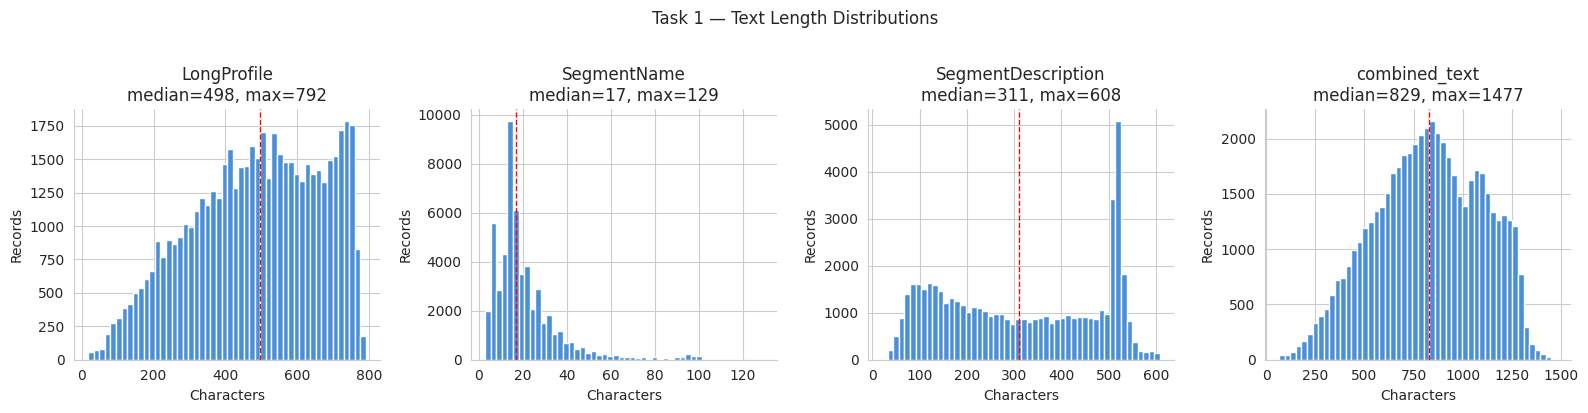

                    min  p25  median   p75   p99   max
LongProfile          18  352     498   638   768   792
SegmentName           3   13      17    26    93   129
SegmentDescription   21  159     311   488   570   608
combined_text        67  629     829  1042  1314  1477


In [6]:
text_cols = ['LongProfile', 'SegmentName', 'SegmentDescription', 'combined_text']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, text_cols):
    lens = df1[col].str.len()
    ax.hist(lens, bins=50, color='#4a90d9', edgecolor='white')
    ax.set_title(f'{col}\nmedian={int(lens.median())}, max={int(lens.max())}')
    ax.set_xlabel('Characters')
    ax.set_ylabel('Records')
    ax.axvline(lens.median(), color='red', linestyle='--', lw=1)

plt.suptitle('Task 1 — Text Length Distributions', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Detailed stats
text_stats = pd.DataFrame({
    col: {
        'min':    int(df1[col].str.len().min()),
        'p25':    int(df1[col].str.len().quantile(0.25)),
        'median': int(df1[col].str.len().median()),
        'p75':    int(df1[col].str.len().quantile(0.75)),
        'p99':    int(df1[col].str.len().quantile(0.99)),
        'max':    int(df1[col].str.len().max()),
    }
    for col in text_cols
}).T
print(text_stats.to_string())

## A5. The 51% Missing SegmentDescription Problem

**This is the most important finding from cleaning.** Half of all rows had no original
segment description — they were filled with `LongProfile[:500] + SegmentName`. We need to
know whether this missingness is random or systematic.

If missingness is **systematic by sector**, certain sectors will have weaker training signal
and the model's per-class F1 will suffer disproportionately there.

If missingness is **random**, the imputation strategy applies uniformly and is less of a concern.

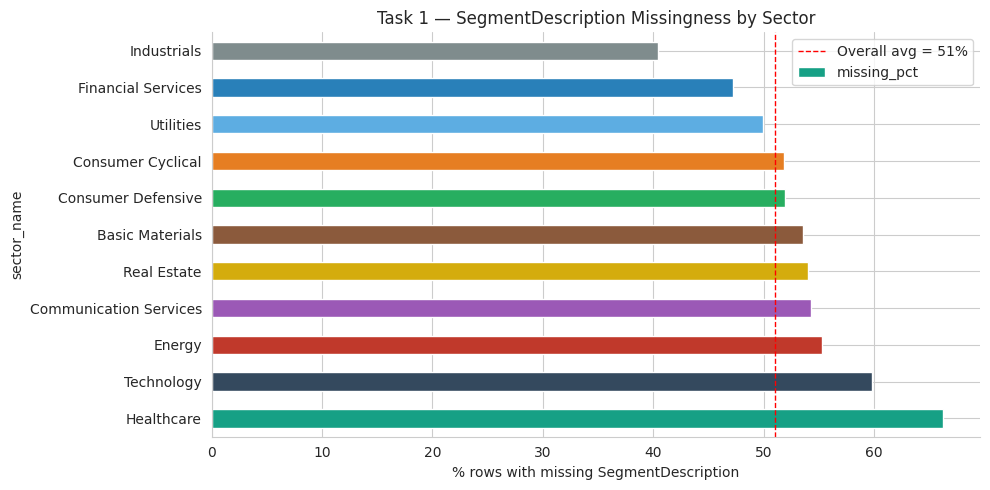

                        total  missing  missing_pct
sector_name                                        
Healthcare               4627     3066    66.263238
Technology               6003     3590    59.803432
Energy                   1706      943    55.275498
Communication Services   2430     1319    54.279835
Real Estate              4001     2161    54.011497
Basic Materials          4560     2441    53.530702
Consumer Defensive       3392     1761    51.916274
Consumer Cyclical        5991     3104    51.811050
Utilities                1714      856    49.941657
Financial Services       7914     3735    47.194845
Industrials             11237     4540    40.402243

Missingness range: 40.4% (best sector) to 66.3% (worst sector)
Spread: 25.9pp
⚠ Missingness is SYSTEMATIC — some sectors much worse than others.
  Per-class F1 will be weaker in high-missingness sectors.


In [7]:
# Missingness by sector
miss_by_sector = (
    df1.groupby('sector_name')['segment_desc_missing']
       .agg(['count', 'sum', 'mean'])
       .rename(columns={'count':'total','sum':'missing','mean':'missing_pct'})
       .sort_values('missing_pct', ascending=False)
)
miss_by_sector['missing_pct'] = miss_by_sector['missing_pct'] * 100

fig, ax = plt.subplots(figsize=(10, 5))
colors = [SECTOR_COLORS.get(s, '#888') for s in miss_by_sector.index]
miss_by_sector['missing_pct'].plot(kind='barh', ax=ax, color=colors)
ax.axvline(51, color='red', linestyle='--', lw=1, label=f'Overall avg = 51%')
ax.set_xlabel('% rows with missing SegmentDescription')
ax.set_title('Task 1 — SegmentDescription Missingness by Sector')
ax.legend()
plt.tight_layout()
plt.show()

print(miss_by_sector.to_string())
print(f'\nMissingness range: {miss_by_sector["missing_pct"].min():.1f}% '
      f'(best sector) to {miss_by_sector["missing_pct"].max():.1f}% (worst sector)')
spread = miss_by_sector['missing_pct'].max() - miss_by_sector['missing_pct'].min()
print(f'Spread: {spread:.1f}pp')
if spread > 20:
    print('⚠ Missingness is SYSTEMATIC — some sectors much worse than others.')
    print('  Per-class F1 will be weaker in high-missingness sectors.')
else:
    print('✓ Missingness is roughly UNIFORM — imputation strategy applies evenly.')

## A6. Segment Structure per Company

How many segments does a typical company report? This affects feature design — a
single-segment company has one row equal to the company; a multi-segment company has
multiple rows that all share the same `MstarGlobal` label.

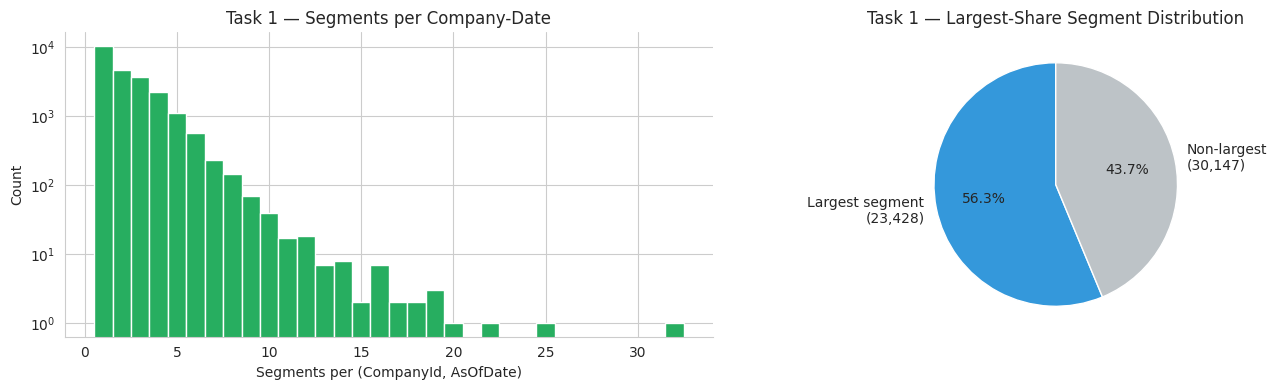

Segments per company-date:
  min    : 1
  median : 2
  mean   : 2.31
  max    : 32
  Single-segment companies: 10,367 (44.7%)


In [8]:
seg_per_company = df1.groupby(['CompanyId','AsOfDate']).size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(seg_per_company, bins=range(1, int(seg_per_company.max()) + 2),
             color='#27ae60', edgecolor='white', align='left')
axes[0].set_xlabel('Segments per (CompanyId, AsOfDate)')
axes[0].set_ylabel('Count')
axes[0].set_title('Task 1 — Segments per Company-Date')
axes[0].set_yscale('log')

# is_largest_share_segment distribution
ils = df1['is_largest_share_segment'].value_counts()
axes[1].pie(ils.values, labels=[f'Largest segment\n({ils.get(True, 0):,})',
                                f'Non-largest\n({ils.get(False, 0):,})'],
            colors=['#3498db', '#bdc3c7'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Task 1 — Largest-Share Segment Distribution')

plt.tight_layout()
plt.show()

print(f'Segments per company-date:')
print(f'  min    : {seg_per_company.min()}')
print(f'  median : {int(seg_per_company.median())}')
print(f'  mean   : {seg_per_company.mean():.2f}')
print(f'  max    : {seg_per_company.max()}')
print(f'  Single-segment companies: {(seg_per_company == 1).sum():,} ({(seg_per_company == 1).mean()*100:.1f}%)')

## A7. Modeling Decision: Segment-level vs Company-level Training

The Task 1 spec says: *"using a company's long-form business description, along with its
self-reported segment names and segment descriptions, to classify the company into the
appropriate GECS industry."*

The label is **company-level** (`MstarGlobal`), but the data is **segment-level rows**.
Two options:

| Option | Approach | Pro | Con |
|---|---|---|---|
| **A. Segment-level training** | Train on each row, aggregate predictions back to company at inference (e.g. weight by `revenue_share`) | More training examples, model sees segment text | Same label repeated for all segments of a company → label imbalance amplified |
| **B. Company-level training** | Collapse all segments per company into one row (concat text), train one row per company | Matches the prediction unit | Loses revenue-share weighting; longer text per row |

**Recommendation:** Try both in `03_baseline.ipynb`. They're easy to A/B.

In [9]:
# Quantify the two scenarios for our planning
n_company_dates = df1.groupby(['CompanyId','AsOfDate']).ngroups
n_companies     = df1['CompanyId'].nunique()

print('Training set size under each option:')
print(f'  A. Segment-level training : {len(df1):,} rows')
print(f'  B. Company-date level     : {n_company_dates:,} rows  ({len(df1)/n_company_dates:.1f}× smaller)')
print(f'  Unique companies          : {n_companies:,}')

Training set size under each option:
  A. Segment-level training : 53,575 rows
  B. Company-date level     : 23,207 rows  (2.3× smaller)
  Unique companies          : 23,207


---
# Section B — Task 2: Sub-Industry Classification

**450 classes (428 observed) | 27,157 rows | text-sparse (189 char median)**

Task 2 has three problems stacked on top of each other: missing classes, rare classes,
and short text. This section quantifies each and lines up the modeling strategy.

## B1. Dataset Overview

Records             : 27,157
Unique companies    : 9,352
Date range          : 2020-05-31 → 2024-12-31
Unique AsOfDates    : 50

SubIndustries observed   : 428 / 450
Parent industries observed: 145 / 145
Sectors observed         : 11 / 11


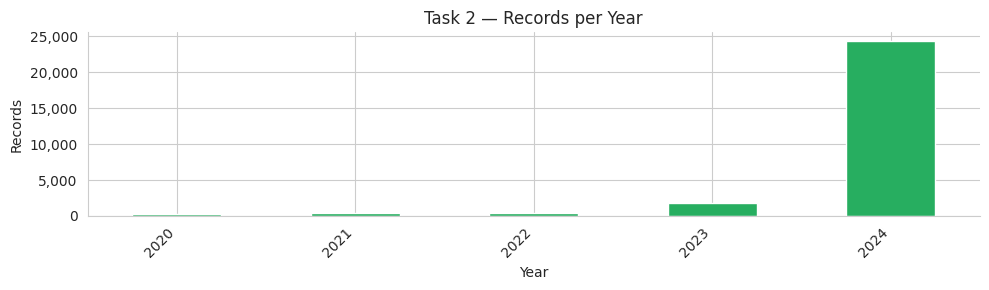

In [10]:
print(f'Records             : {len(df2):,}')
print(f'Unique companies    : {df2["CompanyId"].nunique():,}')
print(f'Date range          : {df2["AsOfDate"].min().date()} → {df2["AsOfDate"].max().date()}')
print(f'Unique AsOfDates    : {df2["AsOfDate"].nunique()}')
print()
print(f'SubIndustries observed   : {df2["SubIndustry"].nunique()} / 450')
print(f'Parent industries observed: {df2["parent_industry_code"].nunique()} / 145')
print(f'Sectors observed         : {df2["sector_code"].nunique()} / 11')

year_counts = df2.groupby(df2['AsOfDate'].dt.year).size()
fig, ax = plt.subplots(figsize=(10, 3))
year_counts.plot(kind='bar', ax=ax, color='#27ae60')
ax.set_title('Task 2 — Records per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Records')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## B2. Hierarchy Distribution

Same charts as Task 1, computed from the decomposed SubIndustry codes.

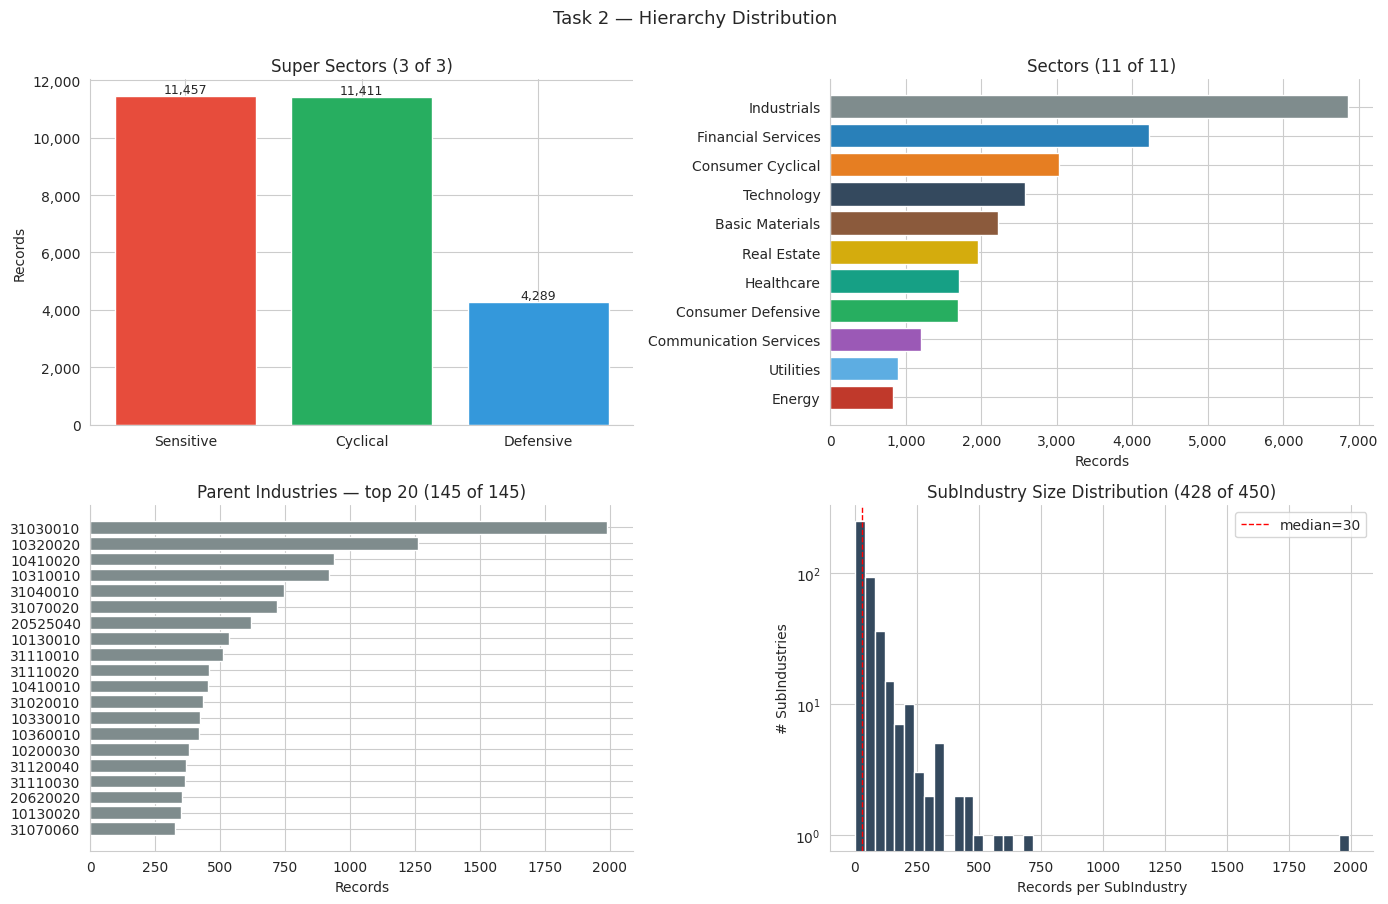

SubIndustry size: min=1  median=30  max=1991  imbalance=1991.0x


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Super Sector
ss2 = df2['super_sector_name'].value_counts()
axes[0,0].bar(ss2.index, ss2.values, color=['#e74c3c','#27ae60','#3498db'])
axes[0,0].set_title(f'Super Sectors ({df2["super_sector_name"].nunique()} of 3)')
axes[0,0].set_ylabel('Records')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, (k, v) in enumerate(ss2.items()):
    axes[0,0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

# Sector
sec2 = df2['sector_name'].value_counts()
colors2 = [SECTOR_COLORS.get(s, '#888') for s in sec2.index]
axes[0,1].barh(sec2.index[::-1], sec2.values[::-1], color=colors2[::-1])
axes[0,1].set_title(f'Sectors ({df2["sector_name"].nunique()} of 11)')
axes[0,1].set_xlabel('Records')
axes[0,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Parent industries — top 20
pi2 = df2['parent_industry_code'].value_counts().head(20)
axes[1,0].barh(pi2.index[::-1], pi2.values[::-1], color='#7f8c8d')
axes[1,0].set_title(f'Parent Industries — top 20 ({df2["parent_industry_code"].nunique()} of 145)')
axes[1,0].set_xlabel('Records')

# SubIndustry size distribution (the label)
sub_counts = df2['SubIndustry'].value_counts()
axes[1,1].hist(sub_counts.values, bins=50, color='#34495e', edgecolor='white')
axes[1,1].set_title(f'SubIndustry Size Distribution ({df2["SubIndustry"].nunique()} of 450)')
axes[1,1].set_xlabel('Records per SubIndustry')
axes[1,1].set_ylabel('# SubIndustries')
axes[1,1].set_yscale('log')
axes[1,1].axvline(sub_counts.median(), color='red', linestyle='--', lw=1,
                  label=f'median={int(sub_counts.median())}')
axes[1,1].legend()

plt.suptitle('Task 2 — Hierarchy Distribution', fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

print(f'SubIndustry size: min={sub_counts.min()}  median={int(sub_counts.median())}  '
      f'max={sub_counts.max()}  imbalance={sub_counts.max()/sub_counts.min():.1f}x')

## B3. Rare-Class Action Plan

The headline number from cleaning was alarming: **21 classes have <2 samples**, **54 have <5**.
But we have a hierarchical fallback option. Quantify exactly how bad the problem is at each
level of the hierarchy — this tells us where to set the prediction target.

In [12]:
def rare_class_table(series, name):
    counts = series.value_counts()
    return {
        'level':              name,
        'n_unique':           counts.shape[0],
        'min_samples':        int(counts.min()),
        'median_samples':     int(counts.median()),
        'max_samples':        int(counts.max()),
        'imbalance_ratio':    f'{counts.max()/counts.min():.0f}x',
        'classes_lt_2':       int((counts < 2).sum()),
        'classes_lt_5':       int((counts < 5).sum()),
        'classes_lt_30':      int((counts < 30).sum()),
        'pct_safe_for_strat': f'{(counts >= 2).mean()*100:.1f}%',
    }

rows = [
    rare_class_table(df2['super_sector_code'],    'Super Sector'),
    rare_class_table(df2['sector_code'],          'Sector'),
    rare_class_table(df2['industry_group_code'],  'Industry Group'),
    rare_class_table(df2['parent_industry_code'], 'Parent Industry'),
    rare_class_table(df2['SubIndustry'],          'SubIndustry (label)'),
]
rare_table = pd.DataFrame(rows)
print('Task 2 — Rare-Class Risk by Hierarchy Level:\n')
print(rare_table.to_string(index=False))
print()
print('Interpretation:')
print('  - At Parent Industry level, stratified split is feasible with all classes intact.')
print('  - At SubIndustry level, 21 classes must be dropped for stratified split.')
print('  - Hierarchical fallback story: predict SubIndustry; report Parent Industry')
print('    when confidence < threshold. Both metrics in the final report.')

Task 2 — Rare-Class Risk by Hierarchy Level:

              level  n_unique  min_samples  median_samples  max_samples imbalance_ratio  classes_lt_2  classes_lt_5  classes_lt_30 pct_safe_for_strat
       Super Sector         3         4289           11411        11457              3x             0             0              0             100.0%
             Sector        11          825            1954         6848              8x             0             0              0             100.0%
     Industry Group        55           23             301         1991             87x             0             0              1             100.0%
    Parent Industry       145            2             119         1991            996x             0             1             11             100.0%
SubIndustry (label)       428            1              30         1991           1991x            21            54            212              95.1%

Interpretation:
  - At Parent Industry level, stratif

## B4. The 22 Missing SubIndustry Codes

22 of the 450 codes never appear in the 2020-2024 data. We can't predict what we've never
seen. Save the list for the Morningstar sync — Morningstar can confirm whether these are
deprecated, region-specific, or just rare in this window.

In [13]:
# We don't have the canonical 450-code list, but the codes we DO see
# tell us the encoding. Build the observed list and flag this for follow-up.
observed_codes = set(df2['SubIndustry'].unique())
print(f'SubIndustry codes observed in data: {len(observed_codes)}')
print(f'SubIndustry codes per spec        : 450')
print(f'Codes absent from 2020-2024 data  : {450 - len(observed_codes)}')
print()
print('⚠ ACTION: ask Morningstar for the canonical 450-code list to identify')
print('  exactly which codes are missing. Then ask whether they should be:')
print('  (a) excluded from scope (deprecated)')
print('  (b) flagged as out-of-distribution at inference')
print('  (c) the model predicts only the 428 observed codes by design')

# Save observed codes for the sync
out_path = OUT_DIR / 'task2_observed_subindustry_codes.txt'
with open(out_path, 'w') as f:
    f.write('# Observed SubIndustry codes in cleaned Task 2 data\n')
    f.write(f'# Total observed: {len(observed_codes)} of 450\n\n')
    for code in sorted(observed_codes):
        f.write(f'{code}\n')
print(f'\nObserved codes saved to: {out_path}')

SubIndustry codes observed in data: 428
SubIndustry codes per spec        : 450
Codes absent from 2020-2024 data  : 22

⚠ ACTION: ask Morningstar for the canonical 450-code list to identify
  exactly which codes are missing. Then ask whether they should be:
  (a) excluded from scope (deprecated)
  (b) flagged as out-of-distribution at inference
  (c) the model predicts only the 428 observed codes by design

Observed codes saved to: ../reports/task2_observed_subindustry_codes.txt


## B5. Text Length Analysis

Task 2 text is **5× shorter** than Task 1 (189 vs 829 char median). This matters for model
selection: very short text favors simple TF-IDF over transformers, since transformers' main
advantage is contextualizing long passages.

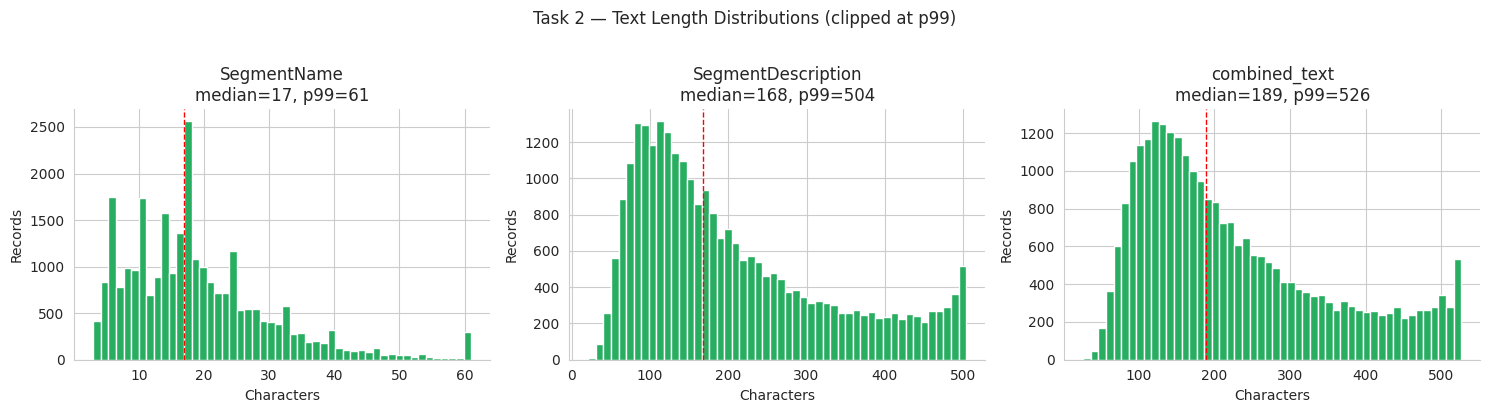

Median text length comparison (combined_text):
  Task 1: 829 chars  (116 words)
  Task 2: 189 chars  (26 words)
  Ratio : Task 2 is 4.4x shorter

Task 2 rows with combined_text < 50 chars: 95 (0.3%)


In [14]:
text_cols2 = ['SegmentName', 'SegmentDescription', 'combined_text']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, text_cols2):
    lens = df2[col].str.len()
    ax.hist(lens.clip(upper=lens.quantile(0.99)), bins=50, color='#27ae60', edgecolor='white')
    ax.set_title(f'{col}\nmedian={int(lens.median())}, p99={int(lens.quantile(0.99))}')
    ax.set_xlabel('Characters')
    ax.set_ylabel('Records')
    ax.axvline(lens.median(), color='red', linestyle='--', lw=1)

plt.suptitle('Task 2 — Text Length Distributions (clipped at p99)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Side-by-side comparison with Task 1
print('Median text length comparison (combined_text):')
print(f'  Task 1: {int(df1["combined_text"].str.len().median())} chars  '
      f'({int(df1["token_est"].median())} words)')
print(f'  Task 2: {int(df2["combined_text"].str.len().median())} chars  '
      f'({int(df2["token_est"].median())} words)')
print(f'  Ratio : Task 2 is {df1["combined_text"].str.len().median()/df2["combined_text"].str.len().median():.1f}x shorter')

# Very-short text rows that will be hard to classify
very_short = (df2['combined_text'].str.len() < 50).sum()
print(f'\nTask 2 rows with combined_text < 50 chars: {very_short:,} ({very_short/len(df2)*100:.1f}%)')

## B6. Investigate Class 3103001001

This single class is **7% of all Task 2 data**. Decoding the code:
`3103001001` → Super=3 (Sensitive), Sector=310 (Industrials), Parent Industry=31030010.

Let's look at what's actually in there to decide whether it's a legitimate dominant activity
or a catch-all bucket. Sample segment names and descriptions are the tell.

In [15]:
DOMINANT = '3103001001'
mask = df2['SubIndustry'] == DOMINANT

print(f'Class {DOMINANT}:')
print(f'  Records          : {mask.sum():,} ({mask.mean()*100:.1f}% of Task 2)')
print(f'  Unique companies : {df2.loc[mask, "CompanyId"].nunique():,}')
print(f'  Unique segments  : {df2.loc[mask, "SegmentName"].nunique():,}')
print(f'  Median text len  : {int(df2.loc[mask, "combined_text"].str.len().median())} chars')
print()
print(f'Top 15 segment names in this class:')
top_segs = df2.loc[mask, 'SegmentName'].value_counts().head(15)
for name, n in top_segs.items():
    print(f'  {n:>5}  {name[:80]}')

# Sample raw segment descriptions
print(f'\n5 random segment descriptions:')
sample = df2.loc[mask, 'SegmentDescription'].sample(5, random_state=42)
for i, desc in enumerate(sample, 1):
    snippet = desc[:200] + ('...' if len(desc) > 200 else '')
    print(f'\n  [{i}] {snippet}')

Class 3103001001:
  Records          : 1,991 (7.3% of Task 2)
  Unique companies : 1,637
  Unique segments  : 968
  Median text len  : 187 chars

Top 15 segment names in this class:
    511  others
    131  other
     40  other business
     36  other businesses
     24  other operations
     18  other activities
     18  all other segments
     18  other segments
     18  other sectors
     15  other departments
     14  corporate
     12  services
     11  energy
     10  all other
     10  other division

5 random segment descriptions:

  [1] leasing business segment is engaged in leasing business, computer processing consignment business

  [2] other business segments include revenue from laundry services, other rentals of properties, revenue generated from the central services and central kitchens, revenue from retail, agency revenue and re...

  [3] other segment comprises principally development and sale of properties, mineral exploration and extraction and investment in a close

**Interpretation:** if the segment names above are a coherent business activity
(e.g. all "industrial conglomerate / diversified operations / corporate"), then it's a real
dominant class and the model should learn it normally. If the names are wildly diverse
("electronics", "food services", "real estate", "energy"), then it's a **catch-all bucket**
and Morningstar uses it when they can't classify — meaning your model will learn to
over-predict it on ambiguous segments.

Bring this finding to the next sync.

---
# Section C — Modeling Readiness Assessment

The deliverable cell. This table goes straight into the project report and the next
Morningstar sync.

In [16]:
def build_readiness_row(df, task_num, label_col, n_classes_spec, parent_col=None):
    counts = df[label_col].value_counts()
    txt_med = int(df['combined_text'].str.len().median())
    n_obs   = df[label_col].nunique()

    # Stratification feasibility
    if (counts < 2).sum() == 0:
        strat_status = '✓ feasible (all classes ≥ 2)'
    else:
        strat_status = f'⚠ {(counts < 2).sum()} classes < 2 samples'

    # Class weight strategy
    imb = counts.max() / counts.min()
    if imb < 100:
        cw = 'class_weight=balanced sufficient'
    elif imb < 1000:
        cw = 'class_weight=balanced + threshold tuning'
    else:
        cw = 'hierarchical fallback required'

    # Text strategy
    if txt_med < 100:
        text_strat = 'TF-IDF favored (text very short)'
    elif txt_med < 500:
        text_strat = 'Both TF-IDF and transformers viable'
    else:
        text_strat = 'Transformers favored (long text)'

    # Top-10 F1 ≥ 0.85 reachability
    top10_size = counts.head(10).sum()
    top10_pct  = top10_size / len(df) * 100

    return {
        'Task':                       f'Task {task_num}',
        'Records':                    f'{len(df):,}',
        'Classes (observed/spec)':    f'{n_obs} / {n_classes_spec}',
        'Class coverage':             f'{n_obs/n_classes_spec*100:.1f}%',
        'Imbalance ratio':            f'{imb:.0f}x',
        'Min samples per class':      int(counts.min()),
        'Stratified split':           strat_status,
        'Class weighting':            cw,
        'Text length (median)':       f'{txt_med} chars',
        'Text strategy':              text_strat,
        'Top-10 % of data':           f'{top10_pct:.1f}%',
    }

t1_row = build_readiness_row(df1, 1, 'MstarGlobal',  145)
t2_row = build_readiness_row(df2, 2, 'SubIndustry',  450)

readiness = pd.DataFrame([t1_row, t2_row]).set_index('Task').T
print('=' * 70)
print('  MODELING READINESS ASSESSMENT')
print('=' * 70)
print(readiness.to_string())
print('=' * 70)

  MODELING READINESS ASSESSMENT
Task                                               Task 1                               Task 2
Records                                            53,575                               27,157
Classes (observed/spec)                         145 / 145                            428 / 450
Class coverage                                     100.0%                                95.1%
Imbalance ratio                                       84x                                1991x
Min samples per class                                  28                                    1
Stratified split             ✓ feasible (all classes ≥ 2)             ⚠ 21 classes < 2 samples
Class weighting          class_weight=balanced sufficient       hierarchical fallback required
Text length (median)                            829 chars                            189 chars
Text strategy            Transformers favored (long text)  Both TF-IDF and transformers viable
Top-10 % of data  

## C1. Specific Modeling Recommendations

Based on the analysis above, the modeling notebook should adopt these defaults.

In [17]:
recs = '''
RECOMMENDATIONS BY TASK
=======================

TASK 1 — Industry Classification (145 classes)
----------------------------------------------
[1] BASELINE: TF-IDF (1-3 grams, max 50k features) + LogisticRegression(class_weight='balanced')
    Expected macro-F1: 0.55-0.70 floor

[2] FEATURE EXPERIMENT: A/B test combined_text vs SegmentName-only vs LongProfile-only
    Goal: quantify how much signal the 51% imputed SegmentDescription is contributing

[3] AGGREGATION EXPERIMENT: Segment-level training vs Company-date-level training
    Goal: determine the right training unit before scaling to transformer models

[4] TRANSFORMER: bge-small-en or all-MiniLM-L6-v2 → mean pool → LogReg head
    Expected macro-F1: 0.70-0.82

[5] SPLIT: GroupShuffleSplit by CompanyId + stratify by sector_name (the label is hierarchical
    so leakage by company is real). Hold out 2024 separately as time-based test.

TASK 2 — SubIndustry Classification (450 spec / 428 observed / 407 trainable)
-----------------------------------------------------------------------------
[1] DROP <2-sample classes for the modeling label space. Document the 21 dropped + 22 absent.

[2] BASELINE: Same TF-IDF + LogReg. Expect macro-F1 in the 0.40-0.55 range — the 1991x
    imbalance and short text make this hard.

[3] HIERARCHICAL FALLBACK (the headline strategy):
    - Train SubIndustry classifier
    - At inference: if max(p) < 0.5, output parent_industry_code (8 digits) instead
    - Report TWO macro-F1 numbers: SubIndustry macro-F1 + Industry-fallback macro-F1
    - This is how we expect to hit >= 0.75 success criterion

[4] CLASS WEIGHTS: 'balanced' alone is insufficient at 1991x. Try sklearn's
    compute_sample_weight + threshold tuning per class.

[5] SPLIT: GroupShuffleSplit by CompanyId + stratify by parent_industry_code (NOT
    SubIndustry — too sparse for stratification).

CROSS-TASK
----------
- Single source of truth for splits in src/data/splits.py — all notebooks import from it
- Track every experiment in results/experiments.csv:
  task, model, features, split_strategy, macro_f1, top10_f1, train_time_s,
  inference_ms_per_row, est_cost_per_1k
- The cost column is in the spec ("comparing prediction quality, system performance,
  and cost for real-world deployment") — track from day 1, not retrofit at the end
'''
print(recs)

# Save to disk
with open(OUT_DIR / 'modeling_recommendations.txt', 'w') as f:
    f.write(recs)
print(f'Saved: {OUT_DIR / "modeling_recommendations.txt"}')


RECOMMENDATIONS BY TASK

TASK 1 — Industry Classification (145 classes)
----------------------------------------------
[1] BASELINE: TF-IDF (1-3 grams, max 50k features) + LogisticRegression(class_weight='balanced')
    Expected macro-F1: 0.55-0.70 floor

[2] FEATURE EXPERIMENT: A/B test combined_text vs SegmentName-only vs LongProfile-only
    Goal: quantify how much signal the 51% imputed SegmentDescription is contributing

[3] AGGREGATION EXPERIMENT: Segment-level training vs Company-date-level training
    Goal: determine the right training unit before scaling to transformer models

[4] TRANSFORMER: bge-small-en or all-MiniLM-L6-v2 → mean pool → LogReg head
    Expected macro-F1: 0.70-0.82

[5] SPLIT: GroupShuffleSplit by CompanyId + stratify by sector_name (the label is hierarchical
    so leakage by company is real). Hold out 2024 separately as time-based test.

TASK 2 — SubIndustry Classification (450 spec / 428 observed / 407 trainable)
----------------------------------------

---
# Section D — Save EDA Artifacts

Persist the readiness table and all summary charts/data so the report writer (you, in
6 weeks) doesn't have to re-run this notebook to recover the numbers.

In [18]:
# Save the readiness table as CSV
readiness.to_csv(OUT_DIR / 'modeling_readiness.csv')
print(f'Saved: {OUT_DIR / "modeling_readiness.csv"}')

# Save the rare-class hierarchy table for Task 2
rare_table.to_csv(OUT_DIR / 'task2_rare_class_by_hierarchy.csv', index=False)
print(f'Saved: {OUT_DIR / "task2_rare_class_by_hierarchy.csv"}')

# Save sector missingness table for Task 1
miss_by_sector.to_csv(OUT_DIR / 'task1_missingness_by_sector.csv')
print(f'Saved: {OUT_DIR / "task1_missingness_by_sector.csv"}')

# Save class size distributions
df1['MstarGlobal'].value_counts().to_csv(OUT_DIR / 'task1_industry_class_sizes.csv',
                                          header=['record_count'])
df2['SubIndustry'].value_counts().to_csv(OUT_DIR / 'task2_subindustry_class_sizes.csv',
                                          header=['record_count'])
print(f'Saved: task1_industry_class_sizes.csv, task2_subindustry_class_sizes.csv')

print(f'\nAll EDA outputs in: {OUT_DIR.absolute()}')

Saved: ../reports/modeling_readiness.csv
Saved: ../reports/task2_rare_class_by_hierarchy.csv
Saved: ../reports/task1_missingness_by_sector.csv
Saved: task1_industry_class_sizes.csv, task2_subindustry_class_sizes.csv

All EDA outputs in: /Users/meetpatel/Documents/capstone/depaul-morningstar-capstone/notebooks/../reports


---
## Summary & Next Steps

### Key Findings
1. **Task 1 is text-rich and class-balanced enough** to clear the success criteria with a
   transformer-based approach. The dominant risk is the 51% missing SegmentDescription —
   verify in baseline experiments whether the imputation strategy helps or hurts.
2. **Task 2 is text-sparse, class-imbalanced, and label-incomplete.** Macro-F1 ≥ 0.75 at
   the SubIndustry level is unlikely without the **hierarchical fallback** strategy.
   Frame the result around dual metrics (SubIndustry macro-F1 + Industry-fallback macro-F1).
3. **Class `3103001001` is 7% of Task 2** — investigate with Morningstar whether it's a
   real activity or a catch-all bucket.
4. **22 SubIndustry codes never appear** in the 2020-2024 data. Get the canonical 450-code
   list from Morningstar to identify exactly which.

### Questions for Next Morningstar Sync
1. What is class `3103001001`? Real dominant activity or catch-all?
2. Of the 22 absent SubIndustry codes — deprecated, region-specific, or just rare?
3. What is the production cost target ($/1k classifications)?
4. Is hierarchical fallback (predict Industry when SubIndustry confidence is low)
   acceptable for production?
5. Can you provide the canonical 450-code SubIndustry list so we can audit coverage?

### Next Notebook
`03_baseline.ipynb` — TF-IDF + Logistic Regression on both tasks. The floor every later
model has to beat.